![header](https://i.imgur.com/I4ake6d.jpg)


# COPERNICUS MARINE SERVICE : Arctic Ocean

<div style="text-align: right"><i> Lesson 3 of 3 - Copernicus Marine Toolbox </i></div>

***
<center><h1> Shrinking sea ice and Atlantic Water: working with data remotely with open_dataset and read_dataframe </h1></center>

***
**General Note 1**: Execute each cell through the <button class="btn btn-default btn-xs"><i class="icon-play fa fa-play"></i></button> button from the top MENU (or keyboard shortcut `Shift` + `Enter`).<br>
<br>
**General Note 2**: If, for any reason, the kernel is not working anymore, in the top MENU, click on the <button class="btn btn-default btn-xs"><i class="fa fa-repeat icon-repeat"></i></button> button. Then, in the top MENU, click on "Run" and select "Run All Above Selected Cell".<br>
<br>
**General Note 3**: Exercises are shown in yellow boxes. Write your answer in the empty cell below each exercise. If you are stuck, a solution can be loaded from the `_solved` folder.<br>
***

# Table of contents

- [1. Introduction](#1.-Introduction)
- [2. Set up Python](#2.-Set-up-Python)
    - [2.1 Required Python modules](#2.1-Required-Python-modules)
    - [2.2 Checking the environment](#2.2-Checking-the-environment)
    - [2.3 Copernicus Marine Toolbox](#2.3-Copernicus-Marine-Toolbox)
        - [2.3.1 Logging in](#2.3.1-Logging-in)
- [3. Working with data without downloading files](#3.-Working-with-data-without-downloading-files)
    - [3.1 The Help Center and the Data Store](#3.1-The-Help-Center-and-the-Data-Store)
    - [3.2 Four ways to access the data](#3.2-Four-ways-to-access-the-data)
    - [3.3 The satellite sea ice record](#3.3-The-satellite-sea-ice-record)
    - [3.4 The Arctic in situ observations](#3.4-The-Arctic-in-situ-observations)
- [4. Sea ice extent with open_dataset](#4.-Sea-ice-extent-with-open_dataset)
    - [4.1 Opening a dataset remotely](#4.1-Opening-a-dataset-remotely)
    - [4.2 Mapping the sea ice](#4.2-Mapping-the-sea-ice)
    - [4.3 Computing the sea ice extent](#4.3-Computing-the-sea-ice-extent)
    - [4.4 Saving the results](#4.4-Saving-the-results)
- [5. Ocean temperature with read_dataframe](#5.-Ocean-temperature-with-read_dataframe)
    - [5.1 Reading in situ data remotely](#5.1-Reading-in-situ-data-remotely)
    - [5.2 Building a temperature time series](#5.2-Building-a-temperature-time-series)
    - [5.3 Saving the results](#5.3-Saving-the-results)
- [6. Exercises to go further](#6.-Exercises-to-go-further)
- [7. Conclusion](#7.-Conclusion)

---
# 1. Introduction

[Go back to the "Table of contents"](#Table-of-contents)

The Arctic is warming about four times faster than the global average, and its sea ice is the most visible sign of this change. Each September, at the end of the melt season, the ice cover reaches its minimum, and this minimum has become much smaller over the last decades. To measure this change, we need to look at **decades** of data, not at a single day.

Part of the heat that melts the ice comes from the ocean itself. Warm **Atlantic Water** flows north along the west coast of Svalbard and enters its fjords, such as **Isfjorden**, the largest fjord of the archipelago. Ships, gliders and buoys regularly measure the temperature of the water at the mouth of the fjord.

Computing a 30-year time series or exploring thousands of measurements would require downloading many files with `get` or `subset`. In this notebook, we will instead use two functions of the Copernicus Marine Toolbox that let you **work with the data directly in Python**, without saving any file first.

| | |
| :--- | :--- |
| **Objective** | Learn how to open gridded data remotely with `open_dataset` and read observations as a table with `read_dataframe`, and how to compute time series from them. |
| **Main questions** | How fast is the Arctic losing its summer sea ice? How does the temperature of the water at the mouth of Isfjorden vary through the year, at the surface and at depth? |
| **Expected outcomes** | You will be able to open a dataset without downloading it, compute a sea ice extent time series and its trend, read in situ observations as a table, build a temperature time series, and save your results. |
| **Duration** | About 1 hour |
| **Prerequisites** | A free [Copernicus Marine account](https://data.marine.copernicus.eu/register) and basic Python knowledge. Knowing the `get` and `subset` functions (lessons 1 and 2) helps, but is not required. |

---
# 2. Set up Python

[Go back to the "Table of contents"](#Table-of-contents)

## 2.1 Required Python modules

[Go back to the "Table of contents"](#Table-of-contents)

The Jupyter Notebook must be set up with all the necessary tools from the Jupyter Notebook ecosystem. Here is the list of the modules we will be using in this notebook.

| Module name | Description |
| :---: | :---|
| **copernicusmarine** | The [Copernicus Marine Toolbox](https://help.marine.copernicus.eu/en/articles/7949409-copernicus-marine-toolbox-introduction) gives access to the Copernicus Marine catalogue and data from Python or from the command line. |
| **xarray** | [Xarray](https://docs.xarray.dev/en/stable/) is a very user-friendly library to manipulate multi-dimensional data such as NetCDF files within Python. It introduces labels in the form of dimensions, coordinates and attributes on top of raw NumPy-like arrays. |
| **dask** | [Dask](https://docs.dask.org/en/stable/) lets xarray work on data that are too large to fit in memory, by loading them piece by piece, only when they are needed. |
| **pandas** | [Pandas](https://pandas.pydata.org/docs/) is a powerful package to manage data tables. |
| **numpy** | [NumPy](https://numpy.org/) is the fundamental package for scientific computing with Python. |
| **matplotlib** | [Matplotlib](https://matplotlib.org/) is a Python 2D plotting library which produces high quality figures. |
| **cartopy** | [Cartopy](https://scitools.org.uk/cartopy/docs/latest/) is a library for plotting maps and geospatial data in Python. |
| **pathlib** | [Pathlib](https://docs.python.org/3/library/pathlib.html) handles file paths in the same way on every operating system. |

We also import a few **helper functions** stored in the `utils` folder: `utils/sea_ice.py` for the sea ice and `utils/insitu.py` for the in situ observations. They hide the technical details (map projections, area computations, table filtering) so that we can focus on the ideas. You can open the files to see how they work.

In [1]:
# To avoid warning messages
import warnings
warnings.filterwarnings("ignore")

# Import libraries
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt

# Helper functions of this training
from utils.arctic_maps import plot_arctic_map
from utils.sea_ice import select_day_each_year, compute_sea_ice_extent, plot_extent_trend
from utils.insitu import (summarize_platforms, plot_platform_positions, keep_good_data,
                          select_depth_layer, monthly_mean, plot_monthly_temperature)

## 2.2 Checking the environment

[Go back to the "Table of contents"](#Table-of-contents)

Let's check the versions of the main packages. This notebook was written for **version 2.5.0** of the Copernicus Marine Toolbox: if your version is older, see the [installation guide](https://help.marine.copernicus.eu/en/articles/7970514-copernicus-marine-toolbox-installation) to update it.

In [2]:
for package in ["copernicusmarine", "xarray", "dask", "pandas", "numpy", "matplotlib", "cartopy"]:
    print(f"{package:<18} {version(package)}")

copernicusmarine   2.5.0b0
xarray             2026.7.0
dask               2026.8.0
pandas             3.0.5
numpy              2.5.3
matplotlib         3.11.1
cartopy            0.25.0


We also create a folder for the results we will save at the end of each part:

In [3]:
data_directory = Path("data")
data_directory.mkdir(exist_ok=True)
print(f"Results will be saved to: {data_directory.resolve()}")

Results will be saved to: /homelocal/gkoenig/Downloads/Training_Toolbox/data


## 2.3 Copernicus Marine Toolbox
[Go back to the "Table of contents"](#Table-of-contents)

The [Copernicus Marine Toolbox](https://help.marine.copernicus.eu/en/articles/7949409-copernicus-marine-toolbox-introduction) is a library that gives access to the Copernicus Marine data from Python code or from the command line.

To import it, we use:

In [4]:
import copernicusmarine

### 2.3.1 Logging in

[Go back to the "Table of contents"](#Table-of-contents)

First, we import the Toolbox and log in. The **login** function asks for the username and password of your Copernicus Marine account, and saves them in a configuration file so that you do not need to enter them again. If you have already logged in during a previous notebook, it simply checks your existing credentials.

If you do not have an account yet, you can create one for free on the [registration page](https://data.marine.copernicus.eu/register).

In [5]:
copernicusmarine.login()

INFO - 2026-10-09T16:04:28Z - Using existing credentials from /homelocal/gkoenig/.copernicusmarine/.copernicusmarine-credentials. Use --force-overwrite combined with credentials (specified by arguments, netrc file or environment variables) to always overwrite.


True

> 📖 **Learn more in the Help Center:** [Toolbox credentials configuration](https://help.marine.copernicus.eu/en/articles/8185007-copernicus-marine-toolbox-credentials-configuration)

---
# 3. Working with data without downloading files

[Go back to the "Table of contents"](#Table-of-contents)

## 3.1 The Help Center and the Data Store

[Go back to the "Table of contents"](#Table-of-contents)

The [Copernicus Marine Help Center](https://help.marine.copernicus.eu/) answers most questions about the Copernicus Marine products and tools. Throughout this notebook, the 📖 boxes point to the articles that go deeper into each topic. A good place to start is [How to access and download Copernicus Marine data](https://help.marine.copernicus.eu/en/articles/16733110-how-to-access-and-download-copernicus-marine-data).

The [Copernicus Marine Data Store](https://data.marine.copernicus.eu/products) lists all the products of the service. You can find a product with the filters ("Variables", "Areas", "Time range", or "Advanced" for more criteria) or by typing its name or ID in the search bar. Each product page has a **Description**, a **Data access** section listing its datasets and their IDs, and a **Documentation** section with the Product User Manual (PUM) and the Quality Information Document (QUID).

> 📖 **Learn more in the Help Center:** [Introduction to the Data Store](https://help.marine.copernicus.eu/en/articles/6722477-introduction-to-the-copernicus-marine-data-store) · [How to search for a product](https://help.marine.copernicus.eu/en/articles/4425061-how-to-search-for-a-product-within-the-copernicus-marine-data-store) · [Products, datasets and their identifiers](https://help.marine.copernicus.eu/en/articles/4703373-differences-between-copernicus-marine-products-and-datasets-and-their-identifiers)

## 3.2 Four ways to access the data

[Go back to the "Table of contents"](#Table-of-contents)

The Copernicus Marine Toolbox offers four functions to access the data. They do not return the same thing, and each one fits a different need:

| Function | What it returns | Saves a file? | Best for |
| :---: | :--- | :---: | :--- |
| `get` | The **original files** of the producer | Yes | Whole files, archives, the producer's own software |
| `subset` | A **selection** (area, period, depths, variables) | Yes | Extracting a region or a period to keep it on disk |
| `open_dataset` | An **xarray dataset**, opened remotely | No | Exploring and computing on gridded data, even very large ones |
| `read_dataframe` | A **pandas table**, loaded in memory | No | Observations, point time series, small selections |

`open_dataset` and `read_dataframe` take the same selection options as `subset` (variables, area, period, depths), but return the data **directly in Python**. With `open_dataset`, the data are only transferred when a computation or a plot needs them: this is called **lazy loading**. If you want to keep a copy, you can still save the result with `.to_netcdf()` or `.to_csv()`.

> 📖 **Learn more in the Help Center:** [Toolbox API - Open a dataset or read a dataframe remotely](https://help.marine.copernicus.eu/en/articles/8287609-copernicus-marine-toolbox-api-open-a-dataset-or-read-a-dataframe-remotely) · [Toolbox data access services](https://help.marine.copernicus.eu/en/articles/7969584-copernicus-marine-toolbox-data-access-services) · [Differences between original files and ARCO data](https://help.marine.copernicus.eu/en/articles/8656000-differences-between-original-producer-files-and-arco-data)

## 3.3 The satellite sea ice record

[Go back to the "Table of contents"](#Table-of-contents)

For the sea ice, we use a **satellite record** of the sea ice concentration, produced by the EUMETSAT Ocean and Sea Ice Satellite Application Facility (OSI SAF). It is based on **passive microwave** sensors (SMMR, SSM/I and SSMIS), which see the sea ice through clouds and during the polar night. Since 1978, they have provided a map of the whole Arctic almost every day: this is one of the longest climate records of the ocean.

| Parameter | Value |
| :---: | :---|
| **Product ID** | [SEAICE_GLO_SEAICE_L4_REP_OBSERVATIONS_011_009](https://data.marine.copernicus.eu/product/SEAICE_GLO_SEAICE_L4_REP_OBSERVATIONS_011_009/description) |
| **Dataset ID** | OSISAF-GLO-SEAICE_CONC_TIMESERIES-NH-LA-OBS (Northern Hemisphere) |
| **Source** | Satellite observations (passive microwave) |
| **Spatial resolution** | 25 km |
| **Temporal resolution** | Daily (every other day until 1987) |
| **Temporal coverage** | From October 1978 to December 2020 |
| **Variable used** | ice_conc (sea ice concentration: percentage of each cell covered by ice, from 0 to 100%) |
| **DOI** | [10.48670/moi-00136](https://doi.org/10.48670/moi-00136) |

| <img src="https://mdl-metadata.s3.waw3-1.cloudferro.com/metadata/thumbnails/SEAICE_GLO_SEAICE_L4_REP_OBSERVATIONS_011_009.jpg" width="400"> |
|:--:|
| Global Ocean Sea Ice Concentration CDRs and ICDRs from PMW data (OSI SAF). - From the [Copernicus Marine Data Store](https://data.marine.copernicus.eu/product/SEAICE_GLO_SEAICE_L4_REP_OBSERVATIONS_011_009/description) |

**For information on how to use the product, please consult the User Manual:** [Product User Manual (PUM)](https://documentation.marine.copernicus.eu/PUM/CMEMS-SEAICE-PUM-011-009.pdf)

**For information about the quality of the product, please consult the document:** [Quality Information Document (QUID)](https://documentation.marine.copernicus.eu/QUID/CMEMS-SEAICE-QUID-011-001-009.pdf)

## 3.4 The Arctic in situ observations

[Go back to the "Table of contents"](#Table-of-contents)

For the ocean temperature, we use the **Arctic Ocean In Situ Near Real Time Observations**, distributed by the Copernicus Marine In Situ Thematic Assembly Centre (INSTAC). It gathers the measurements of many types of platforms (moorings, ships, profiling floats, gliders, drifting buoys...) in a single, quality-controlled collection. Unlike gridded products, these data are **sparse**: each measurement has its own platform, position, depth and time.

| Parameter | Value |
| :---: | :---|
| **Product ID** | [INSITU_ARC_PHYBGCWAV_DISCRETE_MYNRT_013_031](https://data.marine.copernicus.eu/product/INSITU_ARC_PHYBGCWAV_DISCRETE_MYNRT_013_031/description) |
| **Dataset ID** | cmems_obs-ins_arc_phybgcwav_mynrt_na_irr, part "history" |
| **Source** | In situ observations |
| **Spatial coverage** | Arctic Ocean |
| **Temporal resolution** | Irregular: depends on each platform |
| **Variable used** | TEMP (sea water temperature, °C) |
| **DOI** | [10.48670/moi-00031](https://doi.org/10.48670/moi-00031) |

| <img src="https://mdl-metadata.s3.waw3-1.cloudferro.com/metadata/thumbnails/INSITU_ARC_PHYBGCWAV_DISCRETE_MYNRT_013_031.jpg" width="400"> |
|:--:|
| Arctic Ocean In Situ Near Real Time Observations. - From the [Copernicus Marine Data Store](https://data.marine.copernicus.eu/product/INSITU_ARC_PHYBGCWAV_DISCRETE_MYNRT_013_031/description) |

Each in situ dataset has several **parts**: "history" contains the full record of each platform, while "latest" and "monthly" contain the most recent data only. You can also explore the platforms on a map with the [In Situ TAC dashboard](https://marineinsitu.eu/dashboard/).

**For information on how to use the product, please consult the User Manual:** [Product User Manual (PUM)](https://documentation.marine.copernicus.eu/PUM/CMEMS-INS-PUM-013-030-036.pdf)

**For information about the quality of the product, please consult the document:** [Quality Information Document (QUID)](https://documentation.marine.copernicus.eu/QUID/CMEMS-INS-QUID-013-030-036.pdf)

> 📖 **Learn more in the Help Center:** [What is in the PUM?](https://help.marine.copernicus.eu/en/articles/4425095-what-kind-of-information-can-be-found-in-the-pum) · [What is in the QUID?](https://help.marine.copernicus.eu/en/articles/6588555-what-kind-of-information-can-be-found-in-the-quid) · [How to cite Copernicus Marine products](https://help.marine.copernicus.eu/en/articles/4444611-how-to-cite-copernicus-marine-products-and-services)

---
# 4. Sea ice extent with open_dataset

[Go back to the "Table of contents"](#Table-of-contents)

## 4.1 Opening a dataset remotely

[Go back to the "Table of contents"](#Table-of-contents)

`open_dataset` takes the same arguments as `subset`. Here, we only select the variable `ice_conc`, for the whole area and the whole period:

In [6]:
sea_ice_dataset_id = "OSISAF-GLO-SEAICE_CONC_TIMESERIES-NH-LA-OBS"

sea_ice = copernicusmarine.open_dataset(
    dataset_id=sea_ice_dataset_id,
    variables=["ice_conc"],
    service="arco-geo-series"
)
sea_ice

WARNING - 2026-10-09T16:04:34Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
WARNING - 2026-10-09T16:04:34Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
WARNING - 2026-10-09T16:04:34Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
INFO - 2026-10-09T16:04:35Z - Selected dataset version: "202003"
INFO - 2026-10-09T16:04:35Z - Selected dataset part: "default"


<xarray.Dataset> Size: 73GB
Dimensions:    (time: 13674, latitude: 370, longitude: 1800)
Coordinates:
  * time       (time) datetime64[ns] 109kB 1978-10-25T12:00:00 ... 2020-12-31...
  * latitude   (latitude) float64 3kB 16.0 16.2 16.4 16.6 ... 89.4 89.6 89.8
  * longitude  (longitude) float64 14kB -180.0 -179.8 -179.6 ... 179.6 179.8
Data variables:
    ice_conc   (time, latitude, longitude) float64 73GB dask.array<chunksize=(100, 370, 1800), meta=np.ndarray>
Attributes: (12/43)
    Conventions:               CF-1.7,ACDD-1.3
    algorithm:                 SICCI3LF (19V, 37V, 37H)
    cdm_data_type:             Grid
    contributor_name:          Thomas Lavergne,Atle Soerensen,Rasmus Tonboe,C...
    contributor_role:          PrincipalInvestigator,author,author,author,aut...
    creator_email:             osi-saf.helpdesk@meteo.fr
    ...                        ...
    time_coverage_resolution:  P1D
    time_coverage_start:       2020-12-31T00:00:00Z
    title:                     Sea Ice Concentration Climate Data Record Vers...
    topiccategory:             Oceans ClimatologyMeteorologyAtmosphere
    tracking_id:               8d7faebb-f1e2-497a-9a0f-22268b2ecca3
    copernicusmarine_version:  2.5.0b0

The dataset opened in a few seconds, although it covers more than 40 years: **nothing has been downloaded yet**, only its description. Let's check how much data it represents:

In [7]:
print("Number of days:", sea_ice.time.size)
print("Size if it were downloaded (GB):", round(sea_ice["ice_conc"].nbytes / 1e9))

Number of days: 13674
Size if it were downloaded (GB): 73


Several gigabytes for a single variable. With `open_dataset`, we will only transfer the small part we actually need.

<div class="alert alert-block alert-warning">

**Exercise 1**

The record continues after 2020 in another dataset of the same product: `OSISAF-GLO-SEAICE_CONC_CONT_TIMESERIES-NH-LA-OBS`. Open it remotely, for the variable `ice_conc`.

How many days does it contain, and until when does it go?
</div>

<details>
<summary><b>Hint</b> (click to expand)</summary>

Copy the two cells above, change the dataset ID, and use a new variable name, for example `interim_sea_ice`. The last date is `interim_sea_ice.time.values[-1]`.
</details>

In [ ]:
# Write your code here

**Solution:** remove the `#` at the beginning of the next cell and run it. The first run loads the solution into the cell, the second run executes it.

In [10]:
# %load _solved/ARCTBX-03-open-read_exercise-1.py


## 4.2 Mapping the sea ice

[Go back to the "Table of contents"](#Table-of-contents)

Let's map the sea ice in mid-September, close to its yearly minimum, for the first and the last year of the record. With `method="nearest"`, xarray takes the available day closest to the date we ask for. Only these two days are transferred:

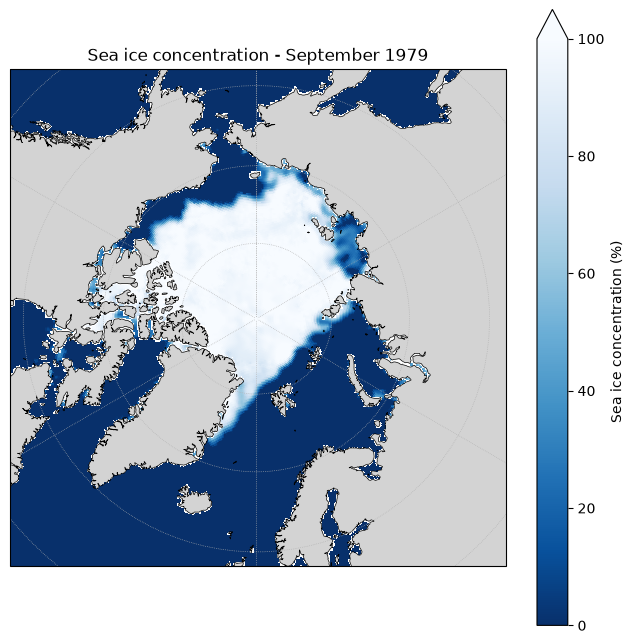

In [11]:
first_september = sea_ice["ice_conc"].sel(time="1979-09-15", method="nearest")

plot_arctic_map(
    first_september,
    "Sea ice concentration - September 1979",
    step=1,
    cmap="Blues_r", vmin=0, vmax=100,
    cbar_kwargs={"label": "Sea ice concentration (%)"},
)
plt.show()

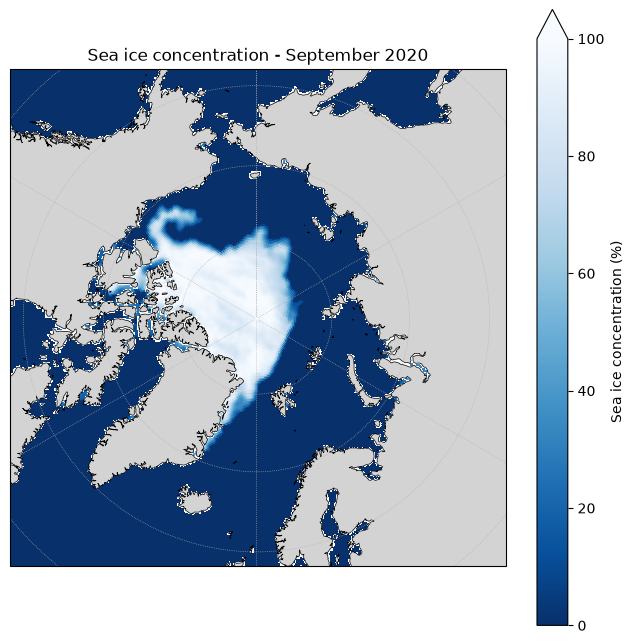

In [12]:
last_september = sea_ice["ice_conc"].sel(time="2020-09-15", method="nearest")

plot_arctic_map(
    last_september,
    "Sea ice concentration - September 2020",
    step=1,
    cmap="Blues_r", vmin=0, vmax=100,
    cbar_kwargs={"label": "Sea ice concentration (%)"},
)
plt.show()

Compare the two maps: in 40 years, the area covered by ice at the end of the summer has clearly shrunk, especially along the coasts of Siberia and Alaska.

<div class="alert alert-block alert-warning">

**Exercise 2**

Do the same for the winter maximum: map the sea ice concentration in **mid-March 1979 and mid-March 2020**.

Does the winter ice cover change as much as the summer one?
</div>

<details>
<summary><b>Hint</b> (click to expand)</summary>

Copy the two cells above and change the dates and the titles: mid-March is `"1979-03-15"`.
</details>

In [ ]:
# Write your code here

**Solution:** remove the `#` at the beginning of the next cell and run it. The first run loads the solution into the cell, the second run executes it.

In [15]:
# %load _solved/ARCTBX-03-open-read_exercise-2.py


## 4.3 Computing the sea ice extent

[Go back to the "Table of contents"](#Table-of-contents)

To measure the change, we need a number: the **sea ice extent**, the total area of the ocean where the ice concentration is **at least 15%**. It is the standard indicator used to follow the Arctic sea ice. To do this efficiently, we first need to reopen the dataset with a different service: **geo-time-series**.

In [16]:
sea_ice_dataset_id = "OSISAF-GLO-SEAICE_CONC_TIMESERIES-NH-LA-OBS"

sea_ice = copernicusmarine.open_dataset(
    dataset_id=sea_ice_dataset_id,
    variables=["ice_conc"],
    service="arco-time-series"
)
sea_ice

WARNING - 2026-10-09T16:05:50Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
WARNING - 2026-10-09T16:05:50Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
WARNING - 2026-10-09T16:05:50Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
INFO - 2026-10-09T16:05:50Z - Selected dataset version: "202003"
INFO - 2026-10-09T16:05:50Z - Selected dataset part: "default"


<xarray.Dataset> Size: 73GB
Dimensions:    (time: 13674, latitude: 370, longitude: 1800)
Coordinates:
  * time       (time) datetime64[ns] 109kB 1978-10-25T12:00:00 ... 2020-12-31...
  * latitude   (latitude) float64 3kB 16.0 16.2 16.4 16.6 ... 89.4 89.6 89.8
  * longitude  (longitude) float64 14kB -180.0 -179.8 -179.6 ... 179.6 179.8
Data variables:
    ice_conc   (time, latitude, longitude) float64 73GB dask.array<chunksize=(2734, 32, 400), meta=np.ndarray>
Attributes: (12/43)
    Conventions:               CF-1.7,ACDD-1.3
    algorithm:                 SICCI3LF (19V, 37V, 37H)
    cdm_data_type:             Grid
    contributor_name:          Thomas Lavergne,Atle Soerensen,Rasmus Tonboe,C...
    contributor_role:          PrincipalInvestigator,author,author,author,aut...
    creator_email:             osi-saf.helpdesk@meteo.fr
    ...                        ...
    time_coverage_resolution:  P1D
    time_coverage_start:       2020-12-31T00:00:00Z
    title:                     Sea Ice Concentration Climate Data Record Vers...
    topiccategory:             Oceans ClimatologyMeteorologyAtmosphere
    tracking_id:               8d7faebb-f1e2-497a-9a0f-22268b2ecca3
    copernicusmarine_version:  2.5.0b0

First, `select_day_each_year` keeps one day per year: the available day closest to 15 September. This selection is also prepared without downloading anything:

In [17]:
september = select_day_each_year(sea_ice["ice_conc"], month=9, day=15)
print("Number of years:", september.time.size)

Number of years: 42


In [19]:
sea_ice["ice_conc"].chunks[0][:5]

(2734, 2734, 2734, 2734, 2734)

Then `compute_sea_ice_extent` adds up the area of all the cells with at least 15% of ice, for each of these days. **This is when the data are transferred**:

In [18]:
september_extent = compute_sea_ice_extent(september)
september_extent

KeyboardInterrupt: 

Finally, `plot_extent_trend` draws the time series with its linear trend:

In [ ]:
plot_extent_trend(september_extent, "September")
plt.show()

The September extent changes a lot from one year to the next, depending on the weather of each summer, but the trend is clearly downward.

<div class="alert alert-block alert-warning">

**Exercise 3**

Compute the sea ice extent in **mid-March** of every year, and plot it together with the September extent.

Which season loses more ice, in million km² per decade? And compared to its mean extent?
</div>

<details>
<summary><b>Hint</b> (click to expand)</summary>

Use `select_day_each_year` with `month=3`, then `compute_sea_ice_extent`. To draw both seasons on the same figure, call `plot_extent_trend` twice before `plt.show()`.
</details>

In [ ]:
# Write your code here

**Solution:** remove the `#` at the beginning of the next cell and run it. The first run loads the solution into the cell, the second run executes it.

In [ ]:
# %load _solved/ARCTBX-03-open-read_exercise-3.py

## 4.4 Saving the results

[Go back to the "Table of contents"](#Table-of-contents)

`open_dataset` does not save anything on disk. To keep a result, we save it with `.to_netcdf()`:

In [ ]:
extent_file = data_directory / "september_sea_ice_extent.nc"
september_extent.to_netcdf(extent_file)
print("Saved to", extent_file)

> 📖 **Learn more in the Help Center:** [Toolbox API - Open a dataset or read a dataframe remotely](https://help.marine.copernicus.eu/en/articles/8287609-copernicus-marine-toolbox-api-open-a-dataset-or-read-a-dataframe-remotely) · [How to open and visualize Copernicus Marine data using Python](https://help.marine.copernicus.eu/en/articles/4854800-how-to-open-and-visualize-copernicus-marine-data-using-python)

---
# 5. Ocean temperature with read_dataframe

[Go back to the "Table of contents"](#Table-of-contents)

## 5.1 Reading in situ data remotely

[Go back to the "Table of contents"](#Table-of-contents)

In situ observations are measurements made directly at sea, by ships, buoys, gliders or floats. `read_dataframe` returns them as a **table** (a pandas DataFrame), with one row per measurement. It loads the data in memory right away, so keep your selection small.

We select the temperature measured at the **mouth of Isfjorden**, from the surface to 200 m, over three years:

In [ ]:
insitu_dataset_id = "cmems_obs-ins_arc_phybgcwav_mynrt_na_irr"

temperature_data = copernicusmarine.read_dataframe(
    dataset_id=insitu_dataset_id,
    dataset_part="history",
    variables=["TEMP"],
    minimum_longitude=12.0,
    maximum_longitude=15.5,
    minimum_latitude=77.8,
    maximum_latitude=78.4,
    minimum_depth=0,
    maximum_depth=200,
    start_datetime="2021-01-01",
    end_datetime="2023-12-31",
)

Let's look at the first rows of the table:

In [ ]:
print("Number of measurements:", len(temperature_data))
temperature_data.head()

Each row is one measurement. The most useful columns are:

- `platform_id` and `platform_type`: which instrument made the measurement
- `time`, `longitude`, `latitude` and `depth`: when and where
- `value`: the temperature, in °C
- `value_qc`: its quality flag, where **1** means good data

Many different platforms measured the temperature here. `summarize_platforms` counts them by type:

In [ ]:
summarize_platforms(temperature_data)

And `plot_platform_positions` shows where they measured:

In [ ]:
plot_platform_positions(temperature_data)
plt.show()

There is no fixed station here: the measurements come from ships (CTD profiles and a FerryBox), a glider and drifting buoys, each passing at different times. To follow the temperature through the year, we will combine all of them.

<div class="alert alert-block alert-warning">

**Exercise 4**

Read the **salinity** (variable `PSAL`) for the same area and period, and count its platforms.

Were the temperature and the salinity measured by the same types of platforms?
</div>

<details>
<summary><b>Hint</b> (click to expand)</summary>

Copy the `read_dataframe` cell, change the variable, and store the result in a new variable, for example `salinity_data`. Then use `summarize_platforms` on it.
</details>

In [ ]:
# Write your code here

**Solution:** remove the `#` at the beginning of the next cell and run it. The first run loads the solution into the cell, the second run executes it.

In [ ]:
# %load _solved/ARCTBX-03-open-read_exercise-4.py

> 📖 **Learn more in the Help Center:** [Toolbox API - Open a dataset or read a dataframe remotely](https://help.marine.copernicus.eu/en/articles/8287609-copernicus-marine-toolbox-api-open-a-dataset-or-read-a-dataframe-remotely) · [Filter in situ original files using index files](https://help.marine.copernicus.eu/en/articles/9630028-filter-and-download-insitu-original-files-using-index-files-with-python)

## 5.2 Building a temperature time series

[Go back to the "Table of contents"](#Table-of-contents)

We build the time series in three steps, each with one function:

1. `keep_good_data` keeps only the measurements flagged as good
2. `select_depth_layer` keeps a range of depths: here, the **surface layer**, from 0 to 10 m
3. `monthly_mean` averages all the measurements of each month

In [ ]:
good_data = keep_good_data(temperature_data)
surface_data = select_depth_layer(good_data, minimum_depth=0, maximum_depth=10)
surface_monthly = monthly_mean(surface_data)

Let's plot it:

In [ ]:
plot_monthly_temperature(surface_monthly, "Surface (0-10 m)")
plt.show()

The surface temperature follows the seasons: it warms up in summer and cools down in winter. The gaps are months without any measurement: ships come more often in summer than in winter.

<div class="alert alert-block alert-warning">

**Exercise 5**

Build the same time series for the **deeper layer, from 50 to 200 m**, where the warm Atlantic Water flows, and plot it together with the surface.

Where is the seasonal cycle the largest: at the surface or at depth? Why?
</div>

<details>
<summary><b>Hint</b> (click to expand)</summary>

Use `select_depth_layer` with other depths, then `monthly_mean`. To draw both layers on the same figure, call `plot_monthly_temperature` twice before `plt.show()`.
</details>

In [ ]:
# Write your code here

**Solution:** remove the `#` at the beginning of the next cell and run it. The first run loads the solution into the cell, the second run executes it.

In [ ]:
# %load _solved/ARCTBX-03-open-read_exercise-5.py

## 5.3 Saving the results

[Go back to the "Table of contents"](#Table-of-contents)

`read_dataframe` does not save anything on disk either. We save the table with `.to_csv()`, which can be opened in any spreadsheet software:

In [ ]:
csv_file = data_directory / "isfjorden_surface_temperature.csv"
surface_data.to_csv(csv_file, index=False)
print("Saved to", csv_file)

> 📖 **Learn more in the Help Center:** [Download data for multiple points from a CSV with Python](https://help.marine.copernicus.eu/en/articles/7970637-download-data-for-multiple-points-from-a-csv-with-python)

---
# 6. Exercises to go further

[Go back to the "Table of contents"](#Table-of-contents)

<div class="alert alert-block alert-info">

Here is a set of exercises to go further. There are two levels, depending on how much Python code you need to write. If you need help, do not hesitate to look at the [Help Center](https://help.marine.copernicus.eu/) or to contact the service desk: **[servicedesk.cmems@mercator-ocean.eu](mailto:servicedesk.cmems@mercator-ocean.eu)**!

**Beginners**:

- Change the threshold of the sea ice extent from 15% to 50%, with `compute_sea_ice_extent(september, threshold=50)`. How does it change the values and the trend?
- The same product also covers the **Antarctic**, with the dataset `OSISAF-GLO-SEAICE_CONC_TIMESERIES-SH-LA-OBS`. Compute its sea ice extent in mid-February (the southern summer) and in mid-September (the southern winter). Does it follow the same trend as the Arctic?
- Build the monthly time series of the **salinity** you read in exercise 4, at the surface and at depth.

**Intermediate**:

- **Extend the time series until 2025** with the dataset of exercise 1: compute its September extent, and plot the two series together. Do the two datasets connect well in 2020-2021?
- `read_dataframe` also works with **gridded** datasets: it then returns a table with one row per grid point and date. Use it on the [Arctic Ocean Physics Reanalysis](https://data.marine.copernicus.eu/product/ARCTIC_MULTIYEAR_PHY_002_003/description) (dataset `cmems_mod_arc_phy_my_topaz4_P1M`, variable `thetao`) at the mouth of Isfjorden, and compare the model with the observations.
- Do the same with the satellite surface temperature of the product [SEAICE_ARC_PHY_CLIMATE_L4_MY_011_016](https://data.marine.copernicus.eu/product/SEAICE_ARC_PHY_CLIMATE_L4_MY_011_016/description) (dataset `cmems_obs_si_arc_phy_my_L4-DMIOI_P1D-m`, variable `analysed_st`, in kelvin), and compare it with the surface layer of the in situ data.

</div>

---
# 7. Conclusion

[Go back to the "Table of contents"](#Table-of-contents)

<div class="alert alert-block alert-success">
    <b>Congratulations !!</b><br>

And thank you for your attention! :)

In this notebook, you have learned to:

* Open a dataset remotely with `open_dataset`, and check its size without downloading it
* Transfer only the data a map or a computation needs
* Compute the sea ice extent and its trend over four decades of satellite observations
* Read in situ observations as a table with `read_dataframe`
* Build a monthly temperature time series from many different platforms
* Save your results with `.to_netcdf()` and `.to_csv()`

Together with `get` and `subset`, you now know the four ways to access Copernicus Marine data with the Toolbox. As a reminder: use `get` for original files, `subset` to save a selection on disk, `open_dataset` to explore and compute on gridded data, and `read_dataframe` for observations and point time series.

To go further, here are some Help Center articles:

* [Toolbox API - Open a dataset or read a dataframe remotely](https://help.marine.copernicus.eu/en/articles/8287609-copernicus-marine-toolbox-api-open-a-dataset-or-read-a-dataframe-remotely)
* [Toolbox API - Subset](https://help.marine.copernicus.eu/en/articles/8283072-copernicus-marine-toolbox-api-subset) and [Toolbox API - Get original files](https://help.marine.copernicus.eu/en/articles/8286883-copernicus-marine-toolbox-api-get-original-files)
* [How to download data for specific depth levels in Python](https://help.marine.copernicus.eu/en/articles/9521812-how-to-download-data-for-specific-depth-levels-in-python)
* [How to open and visualize Zarr format data](https://help.marine.copernicus.eu/en/articles/8077952-how-to-open-and-visualize-zarr-format-data)
* [Using the Copernicus Marine Toolbox in operational workflows](https://help.marine.copernicus.eu/en/articles/8684964-using-the-copernicus-marine-toolbox-in-operational-workflows)
* [Toolbox FAQ](https://help.marine.copernicus.eu/en/articles/8630590-copernicus-marine-toolbox-faq) and [troubleshooting](https://help.marine.copernicus.eu/en/articles/8632322-copernicus-marine-toolbox-troubleshoots)
* [Copernicus Marine community and trainings](https://help.marine.copernicus.eu/en/collections/3740164-copernicus-marine-community-and-trainings)

This training course is over but we'd love to hear from you about how we could improve it (topics, tools, storytelling, format, speed etc). If you have any question, do not hesitate to contact us at [servicedesk.cmems@mercator-ocean.eu](mailto:servicedesk.cmems@mercator-ocean.eu)!
</div>